In [14]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [25]:
df = joblib.load(
    r'D:\# coding\PYTHON\Society Projects\Team task\cleaned_dataset.pkl')
df.head()

,experience_years,python,java,c_cpp,javascript,typescript,html_css,react,angular_vue,nodejs,...,total_skills,ml_skill_count,web_skill_count,experience_skill_score,education_level_B.Tech / B.E.,education_level_BCA,education_level_M.Tech / MCA,education_level_Self-Taught,programming_score,data_skill_score
0,0,0,0,0,1,1,1,1,0,1,...,9,0,6,0,0.0,0.0,0.0,0.0,2,1
1,2,0,0,0,1,1,1,0,1,1,...,6,0,5,12,0.0,0.0,0.0,0.0,2,0
2,3,1,0,0,0,0,0,0,0,0,...,7,1,0,21,1.0,0.0,0.0,0.0,1,1
5,3,0,0,0,1,0,1,1,0,0,...,5,1,3,15,0.0,1.0,0.0,0.0,1,0
6,1,1,0,0,0,0,0,0,0,0,...,6,3,0,6,0.0,0.0,0.0,0.0,1,3


In [16]:
df.columns

Index(['experience_years', 'python', 'java', 'c_cpp', 'javascript',
       'typescript', 'html_css', 'react', 'angular_vue', 'nodejs',
       'fastapi_flask', 'django', 'sql', 'nosql', 'mongodb', 'postgresql',
       'pandas_numpy', 'scikit_learn', 'deep_learning', 'pytorch_tensorflow',
       'nlp', 'computer_vision', 'docker', 'kubernetes', 'git', 'linux', 'aws',
       'azure_gcp', 'ci_cd', 'terraform', 'cybersecurity_basics',
       'penetration_testing', 'flutter_react_native', 'target_career',
       'total_skills', 'ml_skill_count', 'web_skill_count',
       'experience_skill_score', 'education_level_B.Tech / B.E.',
       'education_level_BCA', 'education_level_M.Tech / MCA',
       'education_level_Self-Taught', 'programming_score', 'data_skill_score'],
      dtype='object')

In [17]:
x = df.iloc[:,1:33]
print("Number of features:", x.shape[1])
print("Number of students:", x.shape[0])

Number of features: 32
Number of students: 1399


In [18]:
x.columns

Index(['python', 'java', 'c_cpp', 'javascript', 'typescript', 'html_css',
       'react', 'angular_vue', 'nodejs', 'fastapi_flask', 'django', 'sql',
       'nosql', 'mongodb', 'postgresql', 'pandas_numpy', 'scikit_learn',
       'deep_learning', 'pytorch_tensorflow', 'nlp', 'computer_vision',
       'docker', 'kubernetes', 'git', 'linux', 'aws', 'azure_gcp', 'ci_cd',
       'terraform', 'cybersecurity_basics', 'penetration_testing',
       'flutter_react_native'],
      dtype='object')

In [26]:
scaler = joblib.load(
    r'D:\# coding\PYTHON\Society Projects\Team task\standard_scaler.pkl')

In [27]:
x_scaled = scaler.transform(x)

In [28]:
x_scaled.shape

(1399, 32)

In [29]:
inertia = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

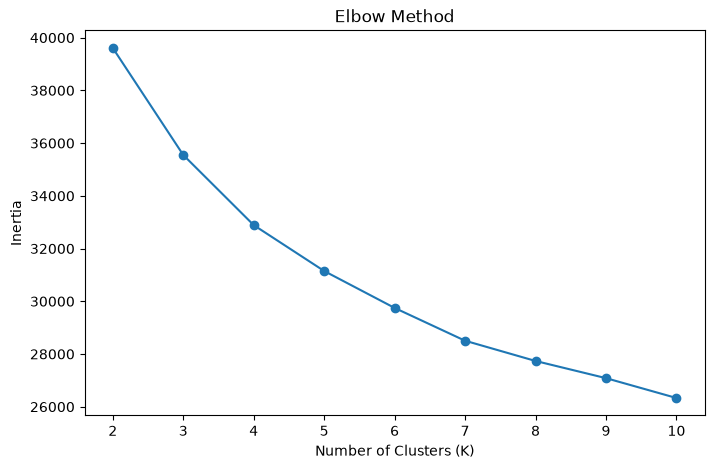

In [30]:
plt.figure(figsize=(8,5))
plt.plot(range(2, 11),inertia,marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [31]:
silhouette_scores = []
for k in range(2, 11): 
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10)    
    labels = kmeans.fit_predict(x_scaled)
    score = silhouette_score(x_scaled, labels)
    silhouette_scores.append(score)    
    print("K =", k, "Silhouette Score =", score)

K = 2 Silhouette Score = 0.1331799848423969
K = 3 Silhouette Score = 0.13785207302256064
K = 4 Silhouette Score = 0.13749382684944944
K = 5 Silhouette Score = 0.14230996091445422
K = 6 Silhouette Score = 0.1457236274819807
K = 7 Silhouette Score = 0.14595229731170703
K = 8 Silhouette Score = 0.1323406022874064
K = 9 Silhouette Score = 0.12943439914875365
K = 10 Silhouette Score = 0.13286176673262828


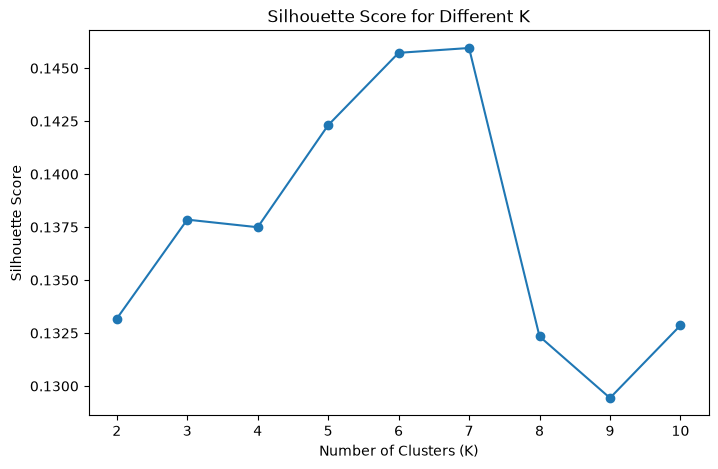

In [32]:
plt.figure(figsize=(8,5))
plt.plot(range(2, 11),silhouette_scores,marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K")
plt.show()

In [33]:
optimal_k = 2

In [34]:
kmeans = KMeans(n_clusters=optimal_k,random_state=42,n_init=10)

cluster_labels = kmeans.fit_predict(x_scaled)

In [36]:
df['cluster'] = cluster_labels
df.head()

,experience_years,python,java,c_cpp,javascript,typescript,html_css,react,angular_vue,nodejs,...,ml_skill_count,web_skill_count,experience_skill_score,education_level_B.Tech / B.E.,education_level_BCA,education_level_M.Tech / MCA,education_level_Self-Taught,programming_score,data_skill_score,cluster
0,0,0,0,0,1,1,1,1,0,1,...,0,6,0,0.0,0.0,0.0,0.0,2,1,0
1,2,0,0,0,1,1,1,0,1,1,...,0,5,12,0.0,0.0,0.0,0.0,2,0,0
2,3,1,0,0,0,0,0,0,0,0,...,1,0,21,1.0,0.0,0.0,0.0,1,1,1
5,3,0,0,0,1,0,1,1,0,0,...,1,3,15,0.0,1.0,0.0,0.0,1,0,0
6,1,1,0,0,0,0,0,0,0,0,...,3,0,6,0.0,0.0,0.0,0.0,1,3,1


In [37]:
print(df['cluster'].value_counts().sort_index())

cluster
0     317
1    1082
Name: count, dtype: int64


In [38]:
pca_2d = PCA(n_components=2)
x_pca_2d = pca_2d.fit_transform(x_scaled)

In [39]:
print(x_pca_2d.shape)

(1399, 2)


In [40]:
pca_df = pd.DataFrame(x_pca_2d,columns=['PC1', 'PC2'])
pca_df['cluster'] = cluster_labels
pca_df.head()

,PC1,PC2,cluster
0,4.729860,1.254357,0
1,4.681148,1.279763,0
2,-0.496974,-2.706923,1
3,2.874930,1.738316,0
4,-1.610448,0.476147,1


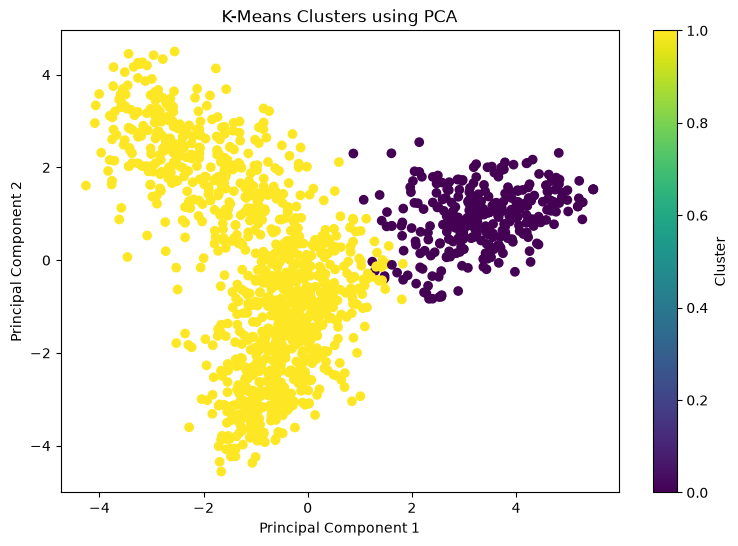

In [42]:
plt.figure(figsize=(9,6))
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['cluster'],
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters using PCA")
plt.colorbar(label="Cluster")
plt.show()

In [43]:
cluster_profile = df.groupby('cluster').mean(numeric_only=True)
cluster_profile

,experience_years,python,java,c_cpp,javascript,typescript,html_css,react,angular_vue,nodejs,...,total_skills,ml_skill_count,web_skill_count,experience_skill_score,education_level_B.Tech / B.E.,education_level_BCA,education_level_M.Tech / MCA,education_level_Self-Taught,programming_score,data_skill_score
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.236593,0.198738,0.208202,0.034700,0.823344,0.744479,0.580442,0.596215,0.198738,0.542587,...,7.372240,0.441640,3.842271,8.892744,0.186120,0.116719,0.148265,0.154574,2.009464,1.012618
1,1.150647,0.762477,0.155268,0.120148,0.038817,0.060074,0.047135,0.039741,0.039741,0.103512,...,8.548983,2.268946,0.754159,9.936229,0.162662,0.130314,0.141405,0.154344,1.136784,2.634011


In [48]:
joblib.dump(kmeans,r'D:\# coding\PYTHON\Society Projects\Team task\kmeans_model.pkl')

['D:\\# coding\\PYTHON\\Society Projects\\Team task\\kmeans_model.pkl']

In [47]:
joblib.dump(pca_2d,r'D:\# coding\PYTHON\Society Projects\Team task\pca_2d.pkl')

['D:\\# coding\\PYTHON\\Society Projects\\Team task\\pca_2d.pkl']